# Modelado

## Carga de Datos Preprocesados

In [ ]:
import numpy as npfrom pathlib import Pathdata_dir = Path("processed_data")X_train = np.load(data_dir / "X_train.npy")X_val = np.load(data_dir / "X_val.npy")X_test = np.load(data_dir / "X_test.npy")y_train = np.load(data_dir / "y_train.npy")y_val = np.load(data_dir / "y_val.npy")y_test = np.load(data_dir / "y_test.npy")feature_names = np.load(data_dir / "feature_names.npy", allow_pickle=True)print(f"Training set:   {X_train.shape[0]:,} samples, {X_train.shape[1]} features")print(f"Validation set: {X_val.shape[0]:,} samples")print(f"Test set:       {X_test.shape[0]:,} samples")

Training set:   15,129 samples, 22 features
Validation set: 3,242 samples
Test set:       3,242 samples


## Métricas de Evaluación

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_scoredef evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, set_name: str = "Set") -> dict:    rmse = np.sqrt(mean_squared_error(y_true, y_pred))    mae = mean_absolute_error(y_true, y_pred)    r2 = r2_score(y_true, y_pred)    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100    print(f"{set_name}:")    print(f"  RMSE: ${rmse:,.0f}")    print(f"  MAE:  ${mae:,.0f}")    print(f"  R²:   {r2:.4f}")    print(f"  MAPE: {mape:.2f}%")    return {"rmse": rmse, "mae": mae, "r2": r2, "mape": mape}

## Modelo Base (Baseline)
Establecemos una línea base antes de entrenar modelos complejos. Un baseline hace la predicción más simple posible — aquí, siempre predice la media del entrenamiento — y establece el piso: cualquier modelo que no pueda superar esto no ofrece información útil.

In [ ]:
from sklearn.dummy import DummyRegressorbaseline = DummyRegressor(strategy="mean")baseline.fit(X_train, y_train)baseline_train = evaluate_model(y_train, baseline.predict(X_train), "Baseline (Training)")baseline_val = evaluate_model(y_val, baseline.predict(X_val), "Baseline (Validation)")

Baseline (Training):
  RMSE: $369,699
  MAE:  $234,035
  R²:   0.0000
  MAPE: 53.72%
Baseline (Validation):
  RMSE: $344,837
  MAE:  $233,456
  R²:   -0.0015
  MAPE: 56.64%


## Selección de Algoritmo
Comparamos múltiples algoritmos con sus **hiperparámetros predeterminados** en el conjunto de validación. El objetivo no es encontrar el mejor modelo posible todavía — es identificar qué familias de algoritmos vale la pena ajustar y cuáles pueden descartarse pronto.

⚠️ **Crítico**: Todas las decisiones de selección de modelo usan el conjunto de validación, no el conjunto de prueba. El conjunto de prueba está reservado exclusivamente para la evaluación final.

### ¿Por qué XGBoost en lugar del `GradientBoostingRegressor` de sklearn?
Los candidatos clásicos de sklearn son Ridge, Lasso y `RandomForestRegressor`. También incluimos **XGBoost** (`XGBRegressor`) en lugar del `GradientBoostingRegressor` de sklearn.

Tanto `GradientBoostingRegressor` como `XGBRegressor` implementan gradient boosting — construyen iterativamente conjuntos aditivos de árboles de decisión donde cada nuevo árbol corrige los residuos de los anteriores. Sin embargo, difieren sustancialmente en la implementación:

| Propiedad | sklearn `GradientBoostingRegressor` | `XGBRegressor` |
|---|---|---|
| Construcción de árboles | Secuencial, divisiones exactas | Basado en histogramas (aproximado) |
| Paralelismo | Ninguno (un árbol a la vez) | A nivel de columna (`n_jobs`) |
| Orden de gradiente | Primer orden (solo gradiente) | Segundo orden (gradiente + Hessiana) |
| Regularización | L2 en valores hoja | L1 (`reg_alpha`) + L2 (`reg_lambda`) incorporados |
| Velocidad | Lento en conjuntos de datos grandes | Mucho más rápido |
| Generalización | Buena | Típicamente mejor por la regularización más rica |

En la práctica, XGBoost (y LightGBM) ha reemplazado en gran medida al `GradientBoostingRegressor` de sklearn como la opción predeterminada para regresión y clasificación tabular. Incluirlo en lugar de este hace la comparación más realista y representativa de cómo se usa realmente el gradient boosting.

In [ ]:
from sklearn.linear_model import Ridge, Lassofrom sklearn.ensemble import RandomForestRegressorfrom xgboost import XGBRegressor# n_jobs=1 on both modelos: GridSearchCV (below) will parallelize across folds.# Setting n_jobs>1 here would cause nested parallelism — see note before the tuning section.models: dict = {    "Ridge": Ridge(alpha=1.0),    "Lasso": Lasso(alpha=1.0, max_iter=100_000),    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1),    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=1),}

In [ ]:
results = []print("Training models (default hyperparameters)...")for name, model in models.items():    model.fit(X_train, y_train)    train_pred = model.predict(X_train)    val_pred = model.predict(X_val)    results.append({        "model": name,        "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),        "train_r2": r2_score(y_train, train_pred),        "val_rmse": np.sqrt(mean_squared_error(y_val, val_pred)),        "val_r2": r2_score(y_val, val_pred),        "val_mae": mean_absolute_error(y_val, val_pred),        "val_mape": np.mean(np.abs((y_val - val_pred) / y_val)) * 100,    })    print(f"  {name}: done")

Training models (default hyperparameters)...
  Ridge: done
  Lasso: done
  RandomForest: done
  XGBoost: done


### Resultados de la Selección Inicial

In [ ]:
import pandas as pdresults_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)display(results_df)

,model,train_rmse,train_r2,val_rmse,val_r2,val_mae,val_mape
0,XGBoost,49968.153513,0.981732,125608.351942,0.867120,71858.677126,13.830907
1,RandomForest,48307.436204,0.982926,127912.364017,0.862201,71847.798786,13.782030
2,Ridge,209807.849754,0.677932,197909.820489,0.670120,131436.864884,28.608921
3,Lasso,209790.376343,0.677986,198048.711408,0.669657,131567.100336,28.636170


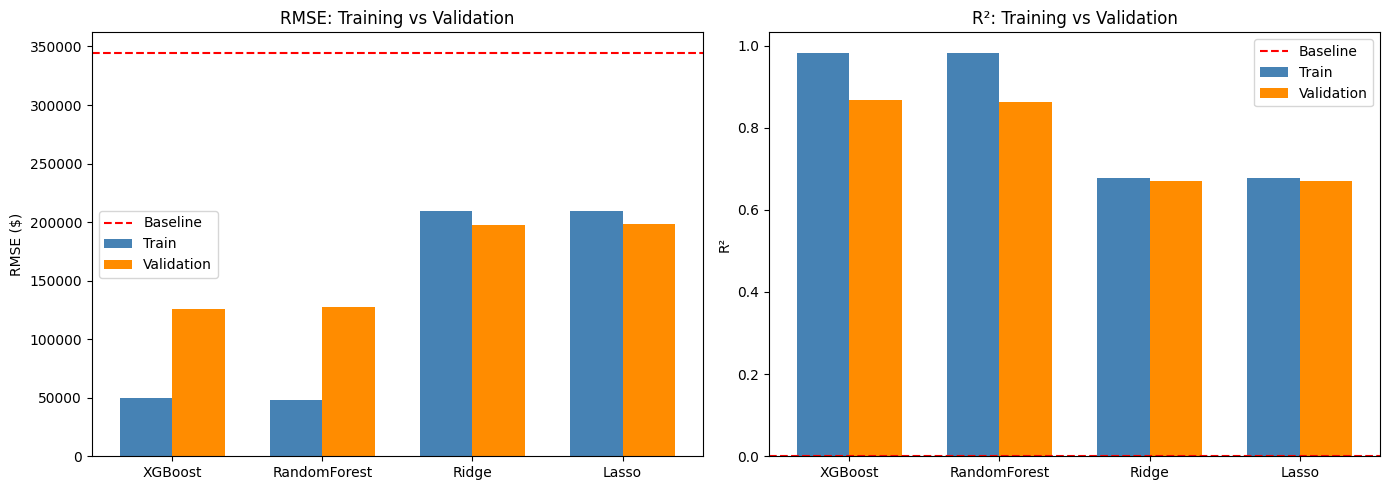

In [ ]:
import matplotlib.pyplot as pltfig, axes = plt.subplots(1, 2, figsize=(14, 5))x = range(len(results_df))width = 0.35axes[0].bar([i - width/2 for i in x], results_df["train_rmse"], width, label="Train", color="steelblue")axes[0].bar([i + width/2 for i in x], results_df["val_rmse"], width, label="Validation", color="darkorange")axes[0].axhline(y=baseline_val["rmse"], color="red", linestyle="--", label="Baseline")axes[0].set_xticks(x)axes[0].set_xticklabels(results_df["model"])axes[0].set_ylabel("RMSE ($)")axes[0].set_title("RMSE: Training vs Validation")axes[0].legend()axes[1].bar([i - width/2 for i in x], results_df["train_r2"], width, label="Train", color="steelblue")axes[1].bar([i + width/2 for i in x], results_df["val_r2"], width, label="Validation", color="darkorange")axes[1].axhline(y=0, color="red", linestyle="--", label="Baseline")axes[1].set_xticks(x)axes[1].set_xticklabels(results_df["model"])axes[1].set_ylabel("R²")axes[1].set_title("R²: Training vs Validation")axes[1].legend()plt.tight_layout()plt.show()

### Candidatos Preseleccionados para Ajuste

In [ ]:
# Linear modelos are already far behind; we shortlist the ensemble methods for tuninglinear_models = {"Ridge", "Lasso"}tuning_candidates = [name for name in results_df["model"] if name not in linear_models]print(f"Shortlisted for tuning: {tuning_candidates}")

Shortlisted for tuning: ['XGBoost', 'RandomForest']


Comparar algoritmos con **hiperparámetros predeterminados** es un primer filtro útil, pero no debe ser la decisión final: los rankings pueden cambiar después del ajuste. Un modelo que aparece segundo en la selección inicial podría superar al ajuste cuidadoso si sus hiperparámetros predeterminados resultan desfavorables.

Por esta razón ajustamos **todos los candidatos preseleccionados** en lugar de solo el aparente ganador. Luego comparamos las versiones ajustadas y hacemos la selección final basada en esa comparación.

### Una nota sobre `n_jobs` y el paralelismo anidado
Tanto `RandomForestRegressor` como `XGBRegressor` aceptan un parámetro `n_jobs` que controla cuántos hilos de CPU usan internamente — construyendo árboles en paralelo en el caso de RF, o muestreo paralelo de columnas en el de XGBoost.

En el paso de selección anterior, configuramos `n_jobs=1` (un solo hilo) para ambos modelos. Esto es intencional.

En el paso de ajuste a continuación, `GridSearchCV` se configura con `n_jobs=-1`, lo que significa que distribuye los pares *(combinación de hiperparámetros × fold)* entre todos los núcleos de CPU disponibles. Si el estimador *también* se ejecutara con `n_jobs=-1`, tendríamos **paralelismo anidado**: `GridSearchCV` genera $K$ procesos trabajadores, cada uno de los cuales genera $M$ hilos dentro del estimador, resultando en $K \times M$ hilos compitiendo por los mismos núcleos. Esto causa contención de hilos — los hilos pasan más tiempo esperando acceso al núcleo que haciendo cómputo real — y el tiempo total de pared típicamente *aumenta* en lugar de disminuir.

**Regla general: paralelizar en un solo nivel.** Deja que `GridSearchCV` tenga el paralelismo externo; mantén el estimador en un solo hilo dentro de él.

## Ajuste de Hiperparámetros
Ajustamos cada candidato preseleccionado usando `GridSearchCV` con validación cruzada `TimeSeriesSplit` sobre el conjunto de entrenamiento.

`TimeSeriesSplit` preserva el orden temporal dentro de los datos de entrenamiento: cada fold usa un fragmento anterior como entrenamiento y un fragmento posterior como validación, simulando la evaluación sobre datos "futuros". Esto previene la fuga de datos durante la búsqueda de hiperparámetros — un simple `KFold` permitiría al modelo "ver" fechas posteriores durante los folds de entrenamiento.

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit# One param grid per candidate; keys must match the names used in the modelos dictparam_grids: dict = {    "RandomForest": {        "n_estimators": [100, 200],        "max_depth": [None, 10, 20],        "min_samples_leaf": [1, 2, 4],    },    "XGBoost": {        "n_estimators": [100, 200],        "max_depth": [3, 5, 7],        "learning_rate": [0.05, 0.1, 0.2],        "reg_lambda": [1, 5],    },}

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)tuned_results = []best_estimators: dict = {}for name in tuning_candidates:    print(f"Tuning {name}...")    grid_search = GridSearchCV(        models[name],        param_grids[name],        cv=tscv,        scoring="neg_root_mean_squared_error",        n_jobs=-1,        verbose=0,    )    grid_search.fit(X_train, y_train)    best_estimators[name] = grid_search.best_estimator_    val_pred = grid_search.best_estimator_.predict(X_val)    val_metrics = evaluate_model(y_val, val_pred, f"{name} (tuned, validation)")    tuned_results.append({        "model": name,        "best_params": str(grid_search.best_params_),        "cv_rmse": -grid_search.best_score_,        "val_rmse": val_metrics["rmse"],        "val_r2": val_metrics["r2"],        "val_mae": val_metrics["mae"],        "val_mape": val_metrics["mape"],    })    print()

Tuning XGBoost...
XGBoost (tuned, validation):
  RMSE: $120,672
  MAE:  $69,890
  R²:   0.8774
  MAPE: 13.54%

Tuning RandomForest...
RandomForest (tuned, validation):
  RMSE: $128,563
  MAE:  $71,791
  R²:   0.8608
  MAPE: 13.73%



In [ ]:
tuned_df = pd.DataFrame(tuned_results).sort_values("val_rmse").reset_index(drop=True)display(tuned_df)best_model_name = tuned_df.iloc[0]["model"]best_model = best_estimators[best_model_name]print(f"\n-> Selected model for test evaluation: {best_model_name} (lowest validation RMSE)")

,model,best_params,cv_rmse,val_rmse,val_r2,val_mae,val_mape
0,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",122116.530672,120671.559997,0.877360,69889.865226,13.538467
1,RandomForest,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",133530.016798,128563.363722,0.860795,71790.963728,13.729384



-> Selected model for test evaluation: XGBoost (lowest validation RMSE)


## Evaluación Final en el Conjunto de Prueba

> ⚠️ **Esta es la ÚNICA vez que usamos el conjunto de prueba.**
>
> El conjunto de prueba representa datos futuros no vistos. Usarlo para cualquier toma de decisiones (selección de modelo, ajuste de hiperparámetros) causaría **fuga en la selección del modelo**.

In [ ]:
test_pred = best_model.predict(X_test)test_metrics = evaluate_model(y_test, test_pred, f"{best_model_name} (Test)")

XGBoost (Test):
  RMSE: $138,493
  MAE:  $79,639
  R²:   0.8643
  MAPE: 13.65%


#### Interpretación del Rendimiento Final del Modelo
Los resultados del conjunto de prueba proporcionan una estimación honesta de cómo funcionará nuestro modelo en casas no vistas de King County:

**R²**: Nuestro modelo explica una gran parte de la varianza en los precios de las casas — un resultado sólido para una tarea de predicción inmobiliaria, donde muchos factores que influyen en el precio (p. ej., la deseabilidad del vecindario, las preferencias del comprador, renovaciones recientes) son difíciles de capturar en datos estructurados. La varianza inexplicada restante probablemente proviene de esos factores no observados.

**RMSE**: El error cuadrático medio raíz representa la magnitud típica de los errores de predicción. El RMSE es sensible a errores grandes, por lo que unas pocas casas caras con errores grandes pueden inflar desproporcionadamente esta métrica en relación con el error mediano.

**MAE**: El error absoluto medio es más robusto ante valores atípicos. La brecha significativa entre RMSE y MAE confirma que nuestro modelo tiene más dificultades con algunas propiedades de alto valor, lo cual es común en la predicción inmobiliaria: la distribución de errores está sesgada a la derecha, impulsada por casas de lujo que son más difíciles de predecir solo con características estructuradas.

**MAPE**: El error porcentual absoluto medio expresa el error de predicción en términos relativos. Esto es particularmente útil para comparar entre diferentes rangos de precios: el mismo error absoluto es proporcionalmente mucho mayor para una casa más barata que para una cara.

**Implicaciones prácticas:**
- Para las casas típicas de rango medio, las predicciones están razonablemente cerca de los precios reales la mayor parte del tiempo
- Para las casas de lujo, la incertidumbre de predicción aumenta significativamente
- El modelo proporciona orientación útil para valoraciones aproximadas pero debe complementar, no reemplazar, las tasaciones profesionales

### Análisis de Predicciones

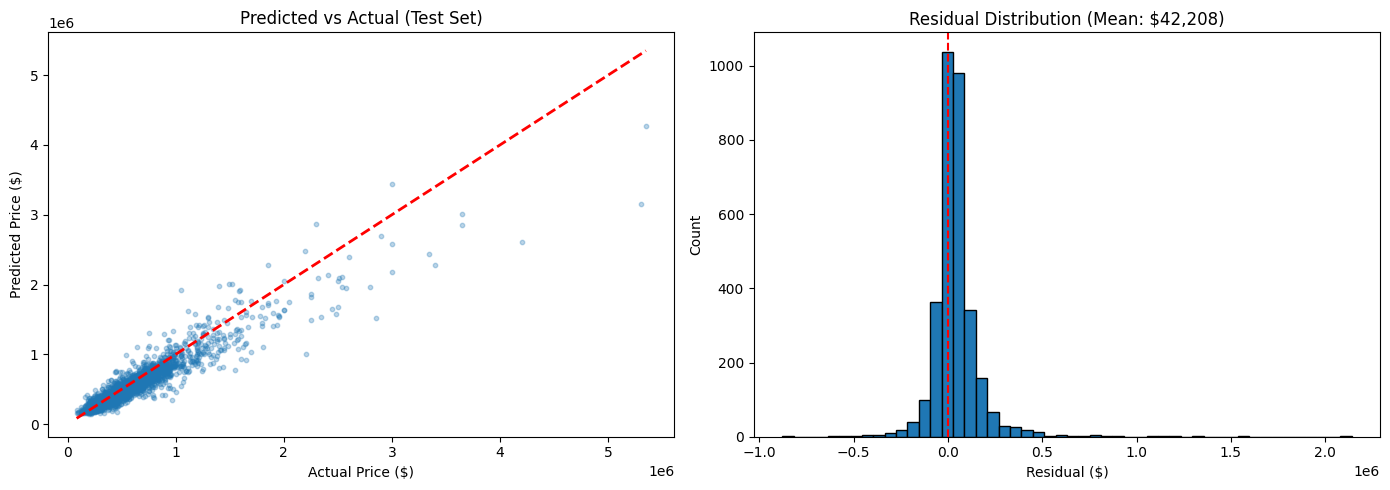

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))# Predicted vs Actualaxes[0].scatter(y_test, test_pred, alpha=0.3, s=10)axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)axes[0].set_xlabel("Actual Price ($)")axes[0].set_ylabel("Predicted Price ($)")axes[0].set_title("Predicted vs Actual (Test Set)")# Residualsresiduals = y_test - test_predaxes[1].hist(residuals, bins=50, edgecolor='black')axes[1].axvline(x=0, color='r', linestyle='--')axes[1].set_xlabel("Residual ($)")axes[1].set_ylabel("Count")axes[1].set_title(f"Residual Distribution (Mean: ${residuals.mean():,.0f})")plt.tight_layout()plt.show()

### Importancia de Características

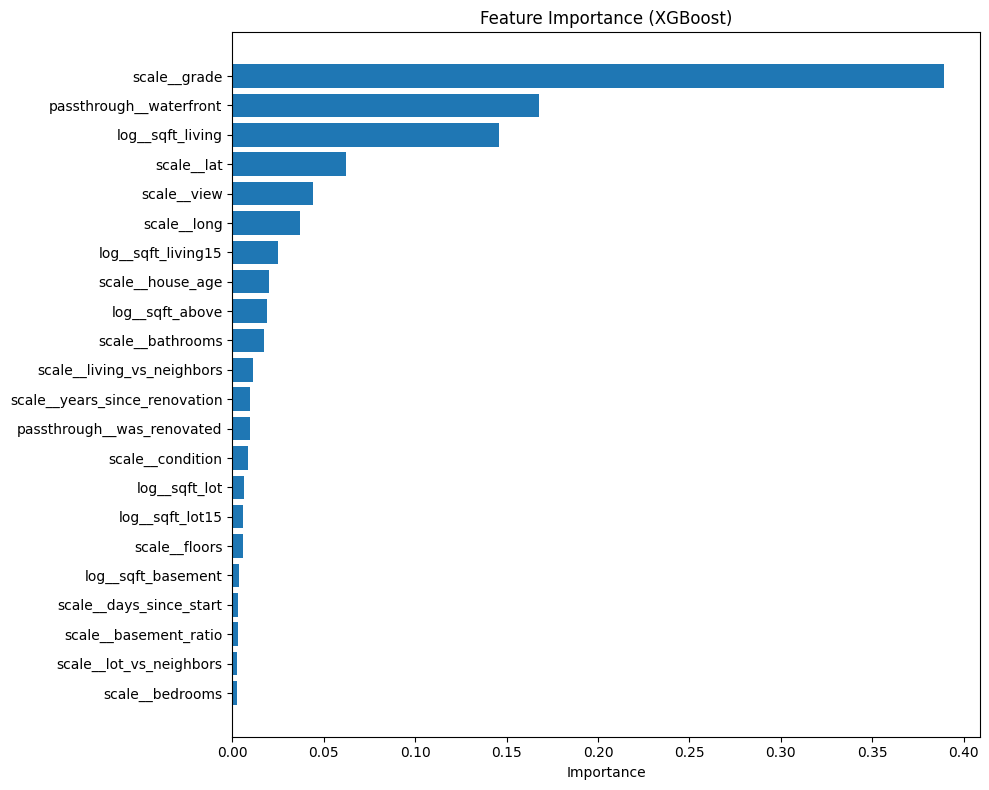


Top 5 features:


,feature,importance
9,scale__view,0.043873
12,scale__lat,0.061914
0,log__sqft_living,0.145875
20,passthrough__waterfront,0.167855
11,scale__grade,0.389526


In [ ]:
if hasattr(best_model, "feature_importances_"):    importance_df = pd.DataFrame({        "feature": feature_names,        "importance": best_model.feature_importances_,    }).sort_values("importance", ascending=True)    plt.figure(figsize=(10, 8))    plt.barh(importance_df["feature"], importance_df["importance"])    plt.xlabel("Importance")    plt.title(f"Feature Importance ({best_model_name})")    plt.tight_layout()    plt.show()    print("\nTop 5 features:")    display(importance_df.tail(5))

## Guardar Modelo Final

In [ ]:
import jobliboutput_dir = Path("processed_data")joblib.dump(best_model, output_dir / "final_model.joblib")print(f"Model saved to {output_dir / 'final_model.joblib'}")

Model saved to processed_data/final_model.joblib


## Resumen

### Resumen de la Metodología
Seguimos un flujo de trabajo de tres etapas:

| Etapa | Qué hicimos |
|-------|-------------|
| Selección inicial | Todos los candidatos con hiperparámetros predeterminados, evaluados en el conjunto de validación |
| Ajuste | Solo candidatos ensemble; `GridSearchCV` + validación cruzada `TimeSeriesSplit` |
| Evaluación final | El mejor modelo ajustado evaluado en el conjunto de prueba **una sola vez** |

| División | Propósito | Cuándo se usa |
|----------|---------|---------------|
| Entrenamiento (70%) | Ajustar modelos, folds de validación cruzada | A lo largo del proceso |
| Validación (15%) | Selección de modelo, ajuste de hiperparámetros | Durante el desarrollo |
| Prueba (15%) | Evaluación final | Una vez, al final |

### Por Qué Esto Importa
1. La **división temporal** previene la fuga de información futura
2. El **conjunto de validación** previene la fuga en la selección del modelo
3. El **ajuste de múltiples modelos** evita promover un candidato cuyos hiperparámetros predeterminados parecían buenos por casualidad
4. El **aislamiento del conjunto de prueba** da una estimación imparcial del rendimiento

### Resultados

In [ ]:
print(f"Final model: {best_model_name}")print(f"Best parameters: {tuned_df.iloc[0]['best_params']}")print()print("Test Set Performance:")print(f"  RMSE: ${test_metrics['rmse']:,.0f}")print(f"  MAE:  ${test_metrics['mae']:,.0f}")print(f"  R²:   {test_metrics['r2']:.4f}")print(f"  MAPE: {test_metrics['mape']:.2f}%")

Final model: XGBoost
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_lambda': 1}

Test Set Performance:
  RMSE: $138,493
  MAE:  $79,639
  R²:   0.8643
  MAPE: 13.65%


### Lo Que Aprendimos
1. Las **características geográficas** (lat, lon) están entre los predictores más importantes
2. La **superficie en pies cuadrados** predice fuertemente el precio
3. El **grade** (calidad de construcción) importa significativamente
4. Los métodos ensemble (RandomForest, XGBoost) claramente superan a los modelos lineales para este problema
5. XGBoost y RandomForest representan dos estrategias ensemble fundamentalmente diferentes — boosting vs. bagging — y ambas vale la pena ajustar: su rendimiento relativo depende del conjunto de datos

### Posibles Mejoras
- Añadir características de agrupamiento geográfico (p. ej., k-means sobre lat/lon → pertenencia a cluster como características)
- Combinar varios modelos superiores en ensemble
- Ver el notebook 06 para una comparación con aprendizaje profundo